 ## Controlled numerical experiment ##

We want to verify that our methodology works, by creating a "dummy dataset" from one of the Talys models from our collection. Then we want to verify that the pipeline makes the exact same prediction that the initial model made.

In [1]:
import numpy as np
import re
import os
import h5py
import matplotlib.pyplot as plt
import math

from configs import config, helpers
import calc_likelihood_from_cs as daCode

In [2]:
# Generate Talys models file or, if it already exists, read it.
talysDir = "all_talys_102pd"
modelsFile = "./Input/102pd_talys_models.h5"
files = ["aprod.tot", "pprod.tot"]
modelsN = 100
# modelsN = len(next(os.walk(talysDir))[1])

if os.path.exists(modelsFile):
    print(f"Reading file {modelsFile}")
else:  # create file
    with h5py.File(modelsFile, "w") as h5:
        for i in range(modelsN):
            g = h5.create_group(f"i_{i}")
            for f in files:
                E, cs = np.loadtxt(f"{talysDir}/i_{i}/{f}", usecols=[0, 1]).T
                name = f.split(".")[0]  # "aprod" / "pprod"
                sub = g.create_group(name)
                sub.create_dataset("E", data=E, compression="gzip")
                sub.create_dataset("cs", data=cs, compression="gzip")
    print(f"Created {modelsFile} with {modelsN} models.")

Reading file ./Input/102pd_talys_models.h5


Text(0.5, 0.98, 'Dummy data from model 0')

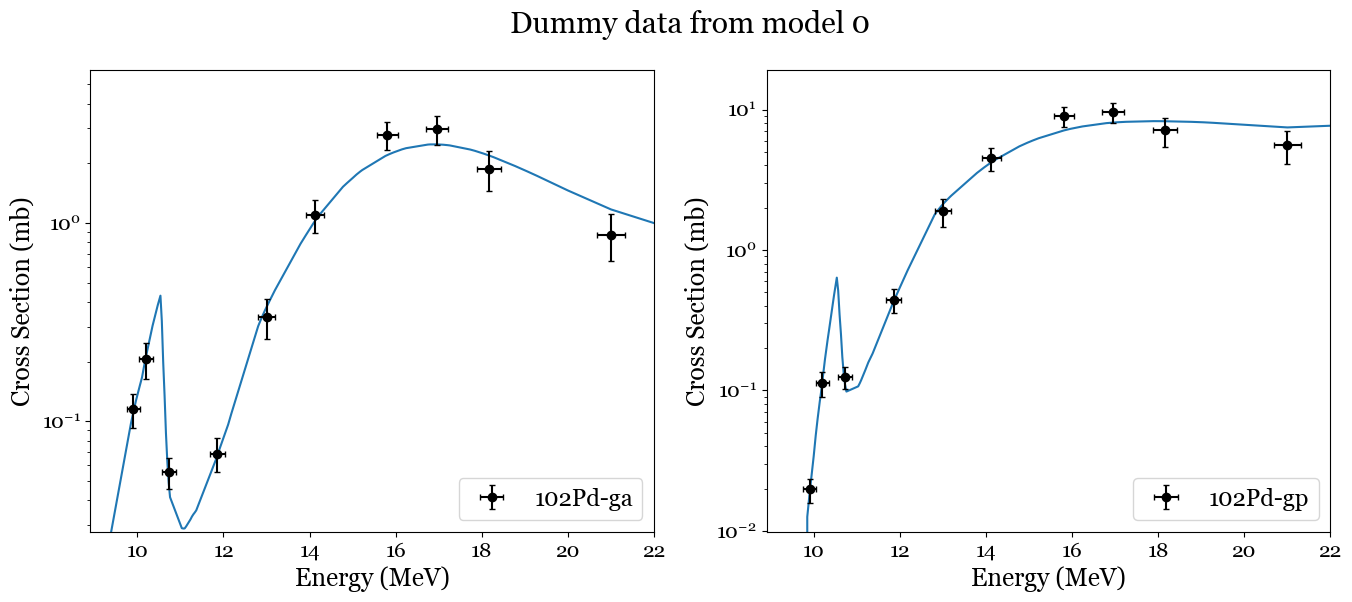

In [3]:
# Based on helpers.read_cs() function, make dummy cross section data from the first model of the h5 file
def make_dummy_cs(fIn, group, n_points=10, rel_err=0.2, seed=0):
    with h5py.File(fIn, "r") as h5:
        E = h5[f"i_0/{group}/E"][:]
        cs = h5[f"i_0/{group}/cs"][:]

    idx = np.linspace(5, len(E) - 5, n_points).astype(int)
    ene_median = E[idx]
    rng = np.random.default_rng(seed)
    cs_true = cs[idx]
    cs_err = rel_err * cs_true
    cs_meas = cs_true + rng.normal(0, 1, size=cs_true.shape) * cs_err

    ene = np.round(ene_median[:, None] * np.linspace(0.985, 1.015, 11), 3)
    return {
        "file": f"{fIn}:i_0/{group}",
        "ene_median": ene_median,
        "ene": ene,
        "cs": cs_meas,
        "cs_err": cs_err,
    }


# the data we provide (simplified version of data dictionary in calc_likelihood_from_cs.py)
groups = {
    "102Pd-ga": {"reaction": "aprod"},
    "102Pd-gp": {"reaction": "pprod"},
}
# make dummy data
cs_data = {
    key: make_dummy_cs(modelsFile, grp["reaction"]) for key, grp in groups.items()
}

# inspect along with the model they came from
fig, axs = daCode.setup_fig(cs_data)
daCode.plot_cs(cs_data, fig, axs)
with h5py.File(modelsFile, "r") as h5:
    axs[0].plot(h5["i_0/aprod/E"][:], h5["i_0/aprod/cs"][:])
    axs[1].plot(h5["i_0/pprod/E"][:], h5["i_0/pprod/cs"][:])
fig.suptitle("Dummy data from model 0")